# JFK daily temperature & monthly degree days
Two NOAA observation versions: **GHCN-Daily USW00094789** and **Aviation Weather METAR KJFK**.

History starts **2000-01-01**; base **65°F**. Forecast snapshots are archived every six hours separately from observations.

GHCN has the long historical record. The Aviation Weather API exposes up to 30 recent days, so its direct version cannot recreate the 2000–present record. The archive grows forward from today. Neither observation feed supplies temperature forecasts: we retain NOAA/NWS hourly gridded forecasts near JFK and aviation TAF forecasts.

Run with the project's `.venv` Python. By default this notebook uses downloaded files without network access.

In [1]:
from pathlib import Path
import os
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.mplconfig'))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import weather_pipeline as w
pd.set_option('display.max_columns', 12)
plt.rcParams.update({'figure.figsize': (12, 4), 'axes.spines.top': False, 'axes.spines.right': False})
print({'station': w.ICAO, 'ghcn_id': w.GHCN_ID, 'start': w.START, 'base_f': w.BASE_F, 'timezone': w.TZ})

{'station': 'KJFK', 'ghcn_id': 'USW00094789', 'start': '2000-01-01', 'base_f': 65.0, 'timezone': 'America/New_York'}


/Users/stevenxu/Documents/ChatGPT/Weather Derivative/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Download and preserve source data
Set the switches to `True` to refresh. Each response is retained with retrieval time, URL, headers, and SHA-256. Forecast runs keep independent snapshots and a manifest; a partial failure raises an error while preserving successful products. TAFs are aviation forecasts, not hourly temperature forecasts.

In [2]:
REFRESH_OBSERVATIONS = False
ARCHIVE_FORECAST_NOW = False
for enabled, collect in [(ARCHIVE_FORECAST_NOW, w.archive_forecasts), (REFRESH_OBSERVATIONS, w.refresh_observations)]:
    if enabled:
        try:
            collect()
        except Exception as exc:
            print('Partial collection; continuing offline build:', exc)

## 2. Clean both daily versions
**GHCN:** parse tenths of °C; reject `-9999` and nonblank NOAA quality flags. Retain measurement/source flags in the audit CSV. Reject reversed extrema and leave gaps unfilled. Temperature is `(TMAX + TMIN) / 2` on NOAA's reported date; historical observing-day conventions may differ from a local calendar day.

**METAR:** keep the latest receipt for duplicate observation times; retain raw reports and QC fields. Apply a broad −60 to 55°C plausibility screen (not equivalent to NOAA climate QC). Average reports within each UTC hour to reduce extra SPECI report weighting. Convert to America/New_York dates, accounting for 23/25-hour DST days. Require every local hourly bin and a finished local day before accepting the daily index. Use the midpoint of the sampled hourly extrema; also export the hourly mean as a diagnostic. Sampled extrema may miss true extremes, so these versions are not interchangeable.

In [3]:
ghcn, metar, comparison = w.build()
summary = pd.DataFrame([
    {'version': name, 'first_date': f.index.min().date(), 'last_date': f.index.max().date(),
     'calendar_rows': len(f), 'accepted_days': int(f.valid_day.sum()), 'missing_or_rejected': int((~f.valid_day).sum())}
    for name, f in [('GHCN-Daily', ghcn), ('METAR', metar)]])
display(summary)
display(ghcn.tail(7))
display(metar.tail(7))

,version,first_date,last_date,calendar_rows,accepted_days,missing_or_rejected
0,GHCN-Daily,2000-01-01,2026-09-18,9758,9757,1
1,METAR,2026-08-18,2026-09-19,33,29,4


element,tmax_c,tmin_c,valid_day,tmean_c,source,tmean_f,hdd65_f_days,cdd65_f_days,receipt_id,retrieved_at_utc
date,,,,,,,,,,
2026-09-12,25.0,16.7,True,20.85,GHCN-Daily,69.53,0.00,4.53,e8e5ff762a1a94e28f53c7df,2026-09-20T03:30:52.161805+00:00
2026-09-13,26.7,21.7,True,24.20,GHCN-Daily,75.56,0.00,10.56,e8e5ff762a1a94e28f53c7df,2026-09-20T03:30:52.161805+00:00
2026-09-14,25.0,16.7,True,20.85,GHCN-Daily,69.53,0.00,4.53,e8e5ff762a1a94e28f53c7df,2026-09-20T03:30:52.161805+00:00
2026-09-15,21.1,14.4,True,17.75,GHCN-Daily,63.95,1.05,0.00,e8e5ff762a1a94e28f53c7df,2026-09-20T03:30:52.161805+00:00
2026-09-16,24.4,15.6,True,20.00,GHCN-Daily,68.00,0.00,3.00,e8e5ff762a1a94e28f53c7df,2026-09-20T03:30:52.161805+00:00
2026-09-17,26.7,20.6,True,23.65,GHCN-Daily,74.57,0.00,9.57,e8e5ff762a1a94e28f53c7df,2026-09-20T03:30:52.161805+00:00
2026-09-18,NaN,NaN,False,NaN,GHCN-Daily,NaN,NaN,NaN,e8e5ff762a1a94e28f53c7df,2026-09-20T03:30:52.161805+00:00


,tmin_c,tmax_c,sampled_hourly_mean_c,observed_hours,expected_hours,coverage,valid_day,tmean_c,source,tmean_f,hdd65_f_days,cdd65_f_days
date,,,,,,,,,,,,
2026-09-13,21.7,26.7,23.237500,24,24,1.000000,True,24.20,METAR sampled hourly extrema,75.56,0.00,10.56
2026-09-14,16.7,25.0,22.245833,24,24,1.000000,True,20.85,METAR sampled hourly extrema,69.53,0.00,4.53
2026-09-15,14.4,21.1,17.900000,24,24,1.000000,True,17.75,METAR sampled hourly extrema,63.95,1.05,0.00
2026-09-16,15.6,24.4,20.683333,24,24,1.000000,True,20.00,METAR sampled hourly extrema,68.00,0.00,3.00
2026-09-17,21.1,26.7,23.466667,24,24,1.000000,True,23.90,METAR sampled hourly extrema,75.02,0.00,10.02
2026-09-18,21.7,28.3,24.575000,24,24,1.000000,True,25.00,METAR sampled hourly extrema,77.00,0.00,12.00
2026-09-19,17.8,21.1,19.195652,23,24,0.958333,False,NaN,METAR sampled hourly extrema,NaN,NaN,NaN


## 3. Monthly heating and cooling indices
For each accepted day, `HDD65 = max(65 − Tmean_F, 0)` and `CDD65 = max(Tmean_F − 65, 0)`, in **°F-days**. Sum daily values, not monthly mean temperatures. Published monthly indices require all calendar days, including leap days. `hdd_partial` and `cdd_partial` show available-day sums with coverage; they are not full-month totals and are never scaled or imputed.

In [4]:
ghcn_monthly = w.monthly(ghcn)
metar_monthly = w.monthly(metar)
display(ghcn_monthly.tail(15).round(2))
display(metar_monthly.round(2))

,valid_days,hdd_partial,cdd_partial,calendar_days,coverage,complete_month,hdd65_f_days,cdd65_f_days
month,,,,,,,,
2025-07,31,0.00,460.92,31,1.00,True,0.00,460.92
2025-08,31,0.00,240.78,31,1.00,True,0.00,240.78
2025-09,30,6.96,141.24,30,1.00,True,6.96,141.24
2025-10,31,219.33,15.60,31,1.00,True,219.33,15.60
2025-11,30,550.62,0.00,30,1.00,True,550.62,0.00
2025-12,31,977.64,0.00,31,1.00,True,977.64,0.00
2026-01,31,1092.57,0.00,31,1.00,True,1092.57,0.00
2026-02,28,982.68,0.00,28,1.00,True,982.68,0.00
2026-03,31,680.37,0.00,31,1.00,True,680.37,0.00


,valid_days,hdd_partial,cdd_partial,calendar_days,coverage,complete_month,hdd65_f_days,cdd65_f_days
month,,,,,,,,
2026-08,13,0.00,114.15,31,0.42,False,NaN,NaN
2026-09,16,1.05,133.42,30,0.53,False,NaN,NaN


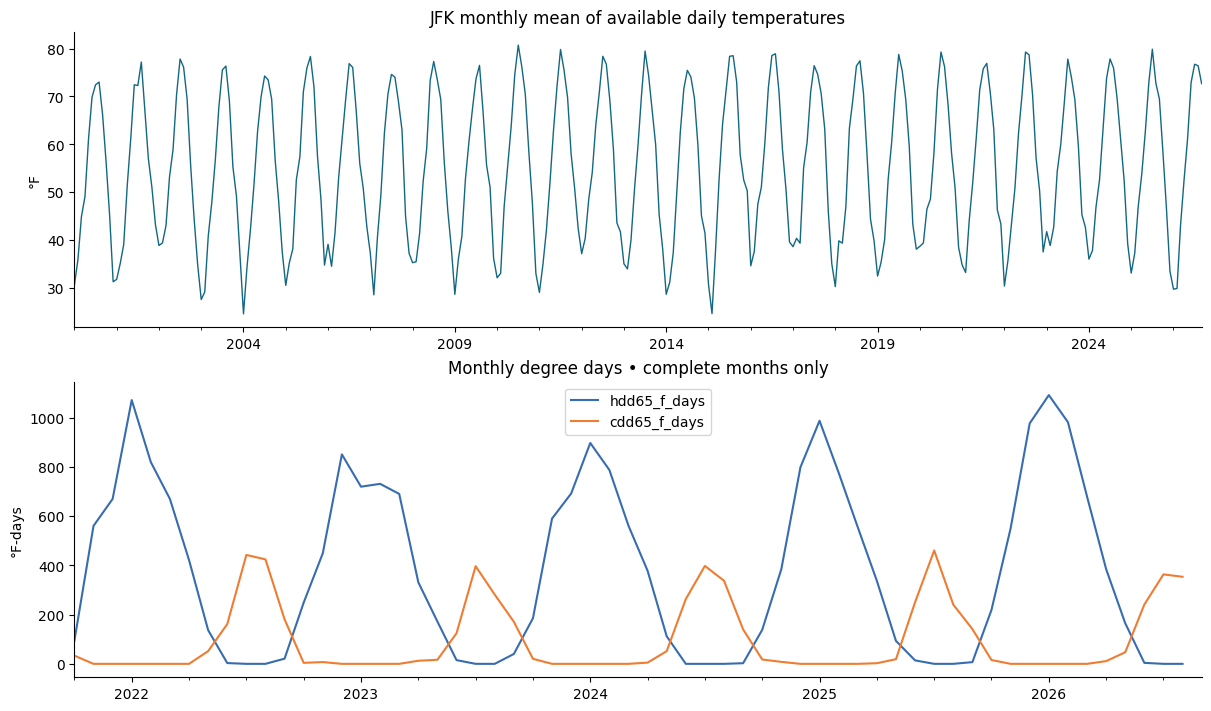

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
ghcn.tmean_f.resample('MS').mean().plot(ax=axes[0], color='#126782', lw=1)
axes[0].set(title='JFK monthly mean of available daily temperatures', ylabel='°F', xlabel='')
p = ghcn_monthly[['hdd65_f_days', 'cdd65_f_days']].copy()
p.index = p.index.to_timestamp()
p.tail(60).plot(ax=axes[1], color=['#386cb0', '#ef7c30'])
axes[1].set(title='Monthly degree days • complete months only', ylabel='°F-days', xlabel='')
plt.show()

## 4. Compare overlapping days
The difference combines observation timing, sampling, and source-processing effects. No bias correction is applied. GHCN reporting latency can reduce the overlap.

Paired accepted days: 28


,tmean_c_ghcn,tmean_c_metar,difference_c
date,,,
2026-08-19,25.55,25.55,-0.00
2026-08-20,23.30,23.30,0.00
2026-08-21,21.95,21.70,-0.25
2026-08-22,23.30,22.20,-1.10
2026-08-23,23.90,23.60,-0.30
2026-08-24,22.75,23.05,0.30
2026-08-25,22.50,22.50,0.00
2026-08-26,22.80,22.80,0.00
2026-08-27,23.60,23.90,0.30


mean_METAR_minus_GHCN_C    0.024107
MAE_C                      0.141964
RMSE_C                     0.266467
dtype: float64

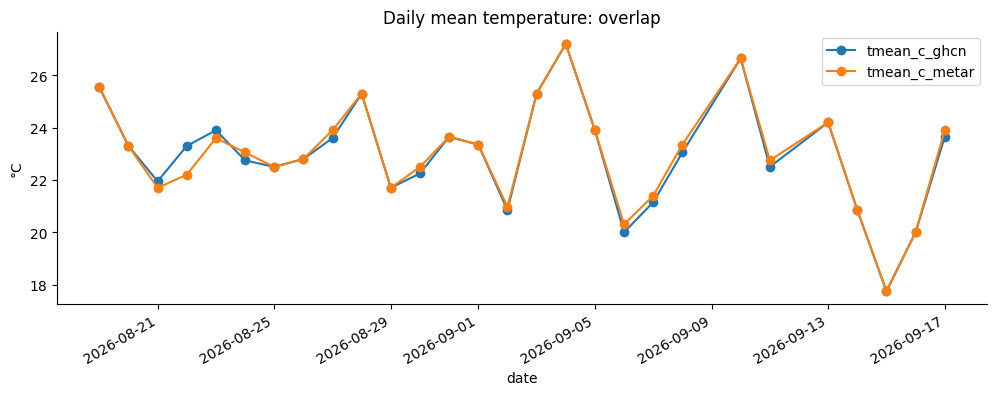

In [6]:
paired = comparison.dropna()
print(f'Paired accepted days: {len(paired)}')
if len(paired):
    display(paired.round(2))
    display(pd.Series({'mean_METAR_minus_GHCN_C': paired.difference_c.mean(),
                       'MAE_C': paired.difference_c.abs().mean(),
                       'RMSE_C': (paired.difference_c.pow(2).mean())**0.5}))
    paired[['tmean_c_ghcn', 'tmean_c_metar']].plot(marker='o', ylabel='°C', title='Daily mean temperature: overlap')
    plt.show()

## 5. Forecast archive
GHCN is refreshed when the last validated retrieval is at least 24 hours old; each rebuild reparses the full snapshot to incorporate revisions. Only successful, structurally validated downloads enter observations. The selection report records fallback and snapshot age. Each six-hour run saves the entire available NWS hourly horizon and current TAF, plus 48 hours of METAR for continued observation coverage. Retrieval, forecast update/generation, and valid times remain distinct. NWS is a grid forecast near JFK, not a station-issued thermometer forecast. The scheduler depends on the Codex desktop host being available; missed snapshots cannot be reconstructed from the current forecast endpoint.

In [7]:
import json
runs = sorted((w.ROOT / 'data/forecasts').glob('*/manifest.json'))
status = []
for path in runs:
    m = json.loads(path.read_text())
    status.append({'retrieved_utc': m['started_at_utc'], 'products': ', '.join(m['products']), 'errors': str(m['errors'])})
display(pd.DataFrame(status))
display(pd.read_csv(w.OUT / 'source_health.csv')[['source', 'last_attempt', 'last_successful_retrieval', 'coverage_end', 'missed_collection', 'stale_success']])
print(json.loads((w.OUT / 'observation_selection.json').read_text())['ghcn'])
latest = sorted((w.ROOT / 'data/forecasts').glob('*/nws_hourly.csv'))[-1]
forecast = pd.read_csv(latest)
display(forecast[['startTime', 'endTime', 'temperature', 'temperatureUnit', 'update_time_utc', 'lead_hours_at_retrieval']].head(12))
print('Latest forecast archive:', latest.parent)

,retrieved_utc,products,errors
0,2026-09-17T21:00:10.430523+00:00,"nws_hourly, taf, metar",{}
1,2026-09-17T21:06:25.497449+00:00,"nws_hourly, taf, metar",{}
2,2026-09-17T21:50:25.772178+00:00,"nws_hourly, taf, metar, ensemble_gfs025, ensem...",{}
3,2026-09-19T02:37:40.295766+00:00,"nws_hourly, taf, metar, ensemble_gfs025, ensem...",{}
4,2026-09-19T02:38:59.714635+00:00,"nws_hourly, taf, metar, ensemble_gfs025, ensem...",{}
5,2026-09-19T13:22:16.470445+00:00,"nws_hourly, taf, metar, ensemble_gfs025, ensem...",{}
6,2026-09-20T02:42:12.337646+00:00,"nws_hourly, taf, metar, ensemble_gfs025, ensem...",{}
7,2026-09-20T02:55:37.221997+00:00,"nws_hourly, taf, metar, ensemble_gfs025, ensem...",{}
8,2026-09-20T03:30:02.254140+00:00,,{'ghcn': 'HTTPSConnectionPool(host=\'www.ncei....
9,2026-09-20T03:30:46.736814+00:00,"ghcn, nws_point, nws_hourly, taf, metar, ensem...",{}


,source,last_attempt,last_successful_retrieval,coverage_end,missed_collection,stale_success
0,ghcn,2026-09-20T03:30:52.161805+00:00,2026-09-20T03:30:52.161805+00:00,2026-09-17,False,False
1,metar,2026-09-20T03:30:53.160508+00:00,2026-09-20T03:30:53.160508+00:00,2026-09-20T02:51:00+00:00,False,False
2,nws_point,2026-09-20T03:30:52.641717+00:00,2026-09-20T03:30:52.641717+00:00,NaN,False,False
3,nws_hourly,2026-09-20T03:30:52.820701+00:00,2026-09-20T03:30:52.820701+00:00,2026-09-26T14:00:00+00:00,False,False
4,taf,2026-09-20T03:30:53.006804+00:00,2026-09-20T03:30:53.006804+00:00,2026-09-21T06:00:00+00:00,False,False
5,ensemble_gfs025,2026-09-20T03:30:54.701172+00:00,2026-09-20T03:30:54.701172+00:00,2026-09-29T20:00:00+00:00,False,False
6,ensemble_ecmwf_ifs025,2026-09-20T03:30:56.730393+00:00,2026-09-20T03:30:56.730393+00:00,2026-10-04T14:00:00+00:00,False,False


{'raw_file': 'data/raw/ghcn/20260920T033052159252Z_39c80c_USW00094789.dly', 'retrieved_at_utc': '2026-09-20T03:30:52.161805+00:00', 'age_hours': 0.08386398333333334, 'fallback': False, 'newer_unusable': [], 'excluded': []}


,startTime,endTime,temperature,temperatureUnit,update_time_utc,lead_hours_at_retrieval
0,2026-09-19T22:00:00-04:00,2026-09-19T23:00:00-04:00,65,F,2026-09-19T18:28:11+00:00,-1.514676
1,2026-09-19T23:00:00-04:00,2026-09-20T00:00:00-04:00,65,F,2026-09-19T18:28:11+00:00,-0.514676
2,2026-09-20T00:00:00-04:00,2026-09-20T01:00:00-04:00,65,F,2026-09-19T18:28:11+00:00,0.485324
3,2026-09-20T01:00:00-04:00,2026-09-20T02:00:00-04:00,64,F,2026-09-19T18:28:11+00:00,1.485324
4,2026-09-20T02:00:00-04:00,2026-09-20T03:00:00-04:00,64,F,2026-09-19T18:28:11+00:00,2.485324
5,2026-09-20T03:00:00-04:00,2026-09-20T04:00:00-04:00,64,F,2026-09-19T18:28:11+00:00,3.485324
6,2026-09-20T04:00:00-04:00,2026-09-20T05:00:00-04:00,62,F,2026-09-19T18:28:11+00:00,4.485324
7,2026-09-20T05:00:00-04:00,2026-09-20T06:00:00-04:00,64,F,2026-09-19T18:28:11+00:00,5.485324
8,2026-09-20T06:00:00-04:00,2026-09-20T07:00:00-04:00,64,F,2026-09-19T18:28:11+00:00,6.485324
9,2026-09-20T07:00:00-04:00,2026-09-20T08:00:00-04:00,64,F,2026-09-19T18:28:11+00:00,7.485324


Latest forecast archive: /Users/stevenxu/Documents/ChatGPT/Weather Derivative/data/forecasts/20260920T033046736669Z_336056


## 6. GEFS and ECMWF ensemble archive
Explicit Open-Meteo models: `gfs025` (31 members, requested 10 days) and `ecmwf_ifs025` (51 members, requested 15 days). The unsuffixed temperature variable is retained as control member 0. We request 2-meter temperatures in °C at JFK, with 2.7 m elevation and land grid selection; requested and returned grid coordinates are both retained.

All returned members and null values are preserved. Hourly API values can be interpolated from 3/6-hour model output. Every six hours we retrieve available data; this collection interval does not guarantee one snapshot of each model initialization. Both products are documented to update every six hours, with publication delays. Metadata is saved before and after the forecast request. An update younger than 10 minutes is flagged for possible server replication delay; another collection can be run later.

Forecast responses do not supply a verifiable initialization timestamp. `initialization_time_utc` remains null. Separate model metadata initialization/availability times are **advisory**, not assigned to every forecast target. `generationtime_ms` measures API computation time, not model initialization. These are retrieval snapshots, potentially containing data from successive runs, not guaranteed single-run hindcasts. Individual-member retention is only up to three past days; this does not reconstruct missed historical vintages.

Identical forecast-content snapshots share a content hash; the analysis table has one row per snapshot/member/target. Member values are stored in Parquet partitions by model and snapshot; snapshot metadata and retrieval receipts hold provenance once. Small coverage and health CSVs remain available. All retrieval receipts and raw responses remain archived. Any changed temperature, null mask, member set, time axis, or grid creates a new snapshot. Matching individual values across distinct snapshots are deliberately retained.

In [8]:
ensemble = w.load_ensemble_archive()
coverage = pd.read_csv(w.OUT / 'ensemble_coverage.csv')
if coverage.empty:
    print('No ensemble archive yet. Run: .venv/bin/python weather_pipeline.py ensembles')
else:
    display(coverage[['model', 'retrieved_at_utc', 'snapshot_id', 'expected_members', 'parsed_members',
                      'members_with_data', 'control_present', 'target_hours', 'missing_values',
                      'complete_requested_window', 'valid_start_utc', 'valid_end_utc', 'warnings']])
    print('Distinct snapshots:', ensemble.snapshot_id.nunique(), '| Unique member-target rows:', len(ensemble))
    print('Verified initialization timestamps:', ensemble.initialization_time_utc.notna().sum())
    display(ensemble[['model', 'member_id', 'member_role', 'requested_latitude', 'requested_longitude',
                      'grid_latitude', 'grid_longitude', 'units', 'target_time_utc', 'temperature_2m',
                      'retrieved_at_utc', 'initialization_time_utc', 'advisory_initialization_time_utc']].head())

,model,retrieved_at_utc,snapshot_id,expected_members,parsed_members,members_with_data,...,target_hours,missing_values,complete_requested_window,valid_start_utc,valid_end_utc,warnings
0,gfs025,2026-09-17T21:50:27.977707+00:00,2b25d93540b30a1eddc2a2088f942b73824922ec9e2786...,31,31,31,...,240,0,True,2026-09-17T00:00:00+00:00,2026-09-26T23:00:00+00:00,[]
1,ecmwf_ifs025,2026-09-17T21:50:30.221473+00:00,f5484fece6577a8a4cb97747fbcd96c176f1ebe25b3aab...,51,51,51,...,360,0,True,2026-09-17T00:00:00+00:00,2026-10-01T23:00:00+00:00,[]
2,gfs025,2026-09-19T02:37:42.745393+00:00,a8a2365491307eb33dc2b832b7de165938c4b29cc33c06...,31,31,31,...,240,93,False,2026-09-19T00:00:00+00:00,2026-09-28T20:00:00+00:00,"[""93 missing temperature values; no imputation""]"
3,ecmwf_ifs025,2026-09-19T02:37:44.947558+00:00,d4d27a2dd2cf9a26bb77bc99131805855785bfbb8fa139...,51,51,51,...,360,459,False,2026-09-19T00:00:00+00:00,2026-10-03T14:00:00+00:00,"[""459 missing temperature values; no imputation""]"
4,gfs025,2026-09-19T02:39:01.892586+00:00,a8a2365491307eb33dc2b832b7de165938c4b29cc33c06...,31,31,31,...,240,93,False,2026-09-19T00:00:00+00:00,2026-09-28T20:00:00+00:00,"[""93 missing temperature values; no imputation""]"
5,ecmwf_ifs025,2026-09-19T02:39:04.212283+00:00,d4d27a2dd2cf9a26bb77bc99131805855785bfbb8fa139...,51,51,51,...,360,459,False,2026-09-19T00:00:00+00:00,2026-10-03T14:00:00+00:00,"[""459 missing temperature values; no imputatio..."
6,gfs025,2026-09-19T13:22:18.849035+00:00,3cd35e3c787b6be5ebf79521372521eb07d478e1cf1ece...,31,31,31,...,240,0,True,2026-09-19T00:00:00+00:00,2026-09-28T23:00:00+00:00,[]
7,ecmwf_ifs025,2026-09-19T13:22:21.058461+00:00,39448a43e4b1b52ca55e5adbe728231e18ab68af5f9277...,51,51,51,...,360,0,True,2026-09-19T00:00:00+00:00,2026-10-03T23:00:00+00:00,[]
8,gfs025,2026-09-20T02:54:30.848048+00:00,cd11fbc3ef46f22969184e6ec9927498663ea8bef4e892...,31,31,31,...,240,93,False,2026-09-20T00:00:00+00:00,2026-09-29T20:00:00+00:00,"[""93 missing temperature values; no imputation""]"
9,ecmwf_ifs025,2026-09-20T02:54:33.092152+00:00,4438723bcd290da56f1bf6e7689bca26014c0d9d186bfc...,51,51,51,...,360,459,False,2026-09-20T00:00:00+00:00,2026-10-04T14:00:00+00:00,"[""459 missing temperature values; no imputatio..."


Distinct snapshots: 8 | Unique member-target rows: 103200
Verified initialization timestamps: 0


,model,member_id,member_role,requested_latitude,requested_longitude,grid_latitude,...,units,target_time_utc,temperature_2m,retrieved_at_utc,initialization_time_utc,advisory_initialization_time_utc
0,ecmwf_ifs025,40,perturbed,40.6392,-73.7639,40.75,...,°C,2026-10-02 16:00:00+00:00,13.1,2026-09-19T13:22:21.058461+00:00,NaN,2026-09-19T00:00:00+00:00
1,ecmwf_ifs025,40,perturbed,40.6392,-73.7639,40.75,...,°C,2026-10-02 06:00:00+00:00,10.4,2026-09-19T13:22:21.058461+00:00,NaN,2026-09-19T00:00:00+00:00
2,ecmwf_ifs025,40,perturbed,40.6392,-73.7639,40.75,...,°C,2026-10-02 07:00:00+00:00,9.9,2026-09-19T13:22:21.058461+00:00,NaN,2026-09-19T00:00:00+00:00
3,ecmwf_ifs025,40,perturbed,40.6392,-73.7639,40.75,...,°C,2026-10-02 08:00:00+00:00,9.5,2026-09-19T13:22:21.058461+00:00,NaN,2026-09-19T00:00:00+00:00
4,ecmwf_ifs025,40,perturbed,40.6392,-73.7639,40.75,...,°C,2026-10-02 09:00:00+00:00,9.1,2026-09-19T13:22:21.058461+00:00,NaN,2026-09-19T00:00:00+00:00


,model,future_target_hours,min_available_members,hours_with_all_expected_members,missing_values_in_future_window
0,gfs025,236,0,233,93
1,ecmwf_ifs025,356,0,347,459


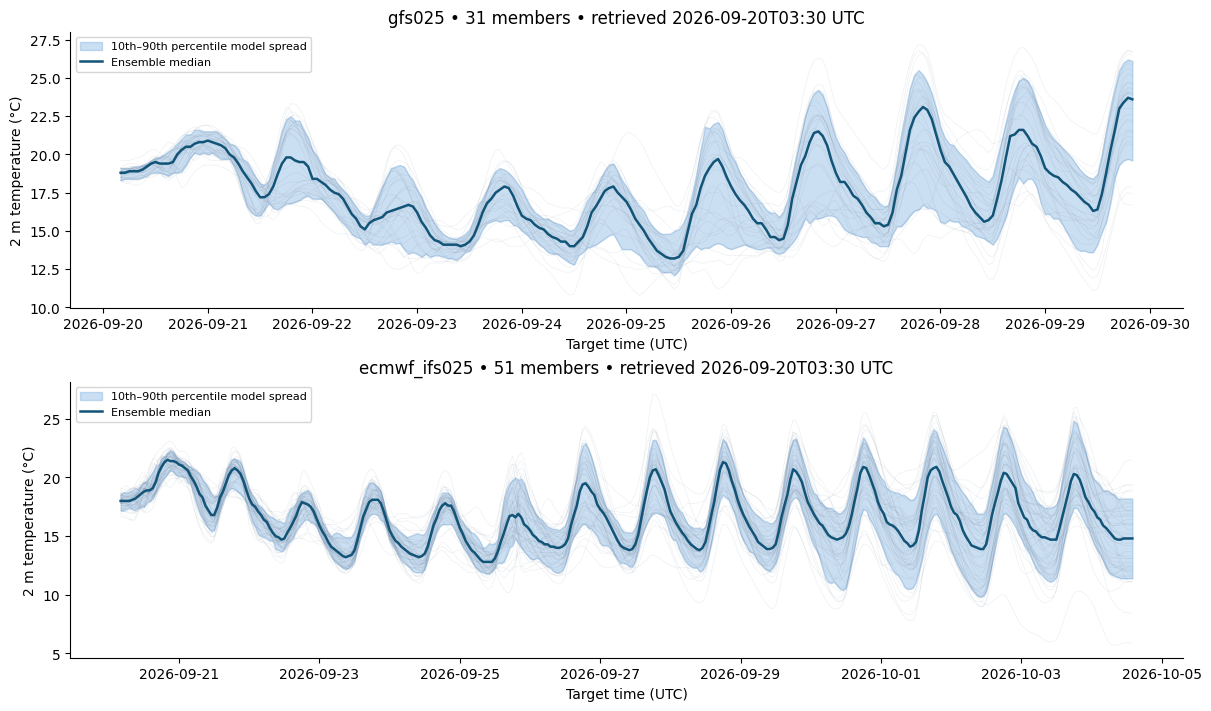

In [9]:
if not coverage.empty:
    latest = coverage.sort_values('retrieved_at_utc').groupby('model', as_index=False).tail(1)
    fig, axes = plt.subplots(len(latest), 1, figsize=(12, 7), squeeze=False, constrained_layout=True)
    member_coverage = []
    for ax, (_, receipt) in zip(axes.flat, latest.iterrows()):
        f = ensemble[ensemble.snapshot_id == receipt.snapshot_id].copy()
        f['target_time_utc'] = pd.to_datetime(f.target_time_utc, utc=True)
        # Plot future targets relative to this retrieval, not an invented run time.
        f = f[f.target_time_utc >= pd.Timestamp(receipt.retrieved_at_utc)]
        wide = f.pivot(index='target_time_utc', columns='member_id', values='temperature_c')
        counts = wide.count(axis=1)
        enough = counts == int(receipt.expected_members)
        median = wide.median(axis=1).where(enough)
        lower = wide.quantile(0.1, axis=1).where(enough)
        upper = wide.quantile(0.9, axis=1).where(enough)
        ax.plot(wide.index, wide.values, color='#718096', alpha=0.12, lw=0.5)
        ax.fill_between(wide.index, lower.to_numpy(), upper.to_numpy(), color='#3182ce', alpha=0.25, label='10th–90th percentile model spread')
        ax.plot(wide.index, median, color='#125478', lw=1.8, label='Ensemble median')
        ax.set(title=f"{receipt.model} • {receipt.parsed_members} members • retrieved {receipt.retrieved_at_utc[:16]} UTC", ylabel='2 m temperature (°C)', xlabel='Target time (UTC)')
        ax.legend(fontsize=8)
        member_coverage.append({'model':receipt.model, 'future_target_hours':len(wide),
                               'min_available_members':int(counts.min()) if len(counts) else 0,
                               'hours_with_all_expected_members':int(enough.sum()),
                               'missing_values_in_future_window':int(wide.isna().sum().sum())})
    display(pd.DataFrame(member_coverage))
    plt.show()

The shaded 10th–90th percentile band describes **model spread**, not an automatically calibrated confidence interval. Median/band values are omitted where any expected member is missing. Each panel uses one retrieval snapshot; models and revisions are not pooled. Shared model biases and coastal grid/elevation effects can remain even when spread is narrow.

This stage does not calculate forecast monthly HDD/CDD or derivative prices. A 10- or 15-day forecast window is not a complete calendar month; the historical completeness rules remain unchanged.

Sources: [Open-Meteo Ensemble API](https://open-meteo.com/en/docs/ensemble-api), [publication metadata](https://open-meteo.com/en/docs/model-updates), [control-member convention](https://github.com/open-meteo/open-meteo/discussions/366). Temperature data: NOAA GEFS and ECMWF IFS via Open-Meteo, CC BY 4.0; converted here to long-format tables and empirical member quantiles.

## Outputs and references
Daily and monthly tables, retained observations, quality audit, and source comparison are in `data/processed/`. Immutable source responses are in `data/raw/`; forecast snapshots are in `data/forecasts/`.

- [NOAA GHCN-Daily format and quality flags](https://www.ncei.noaa.gov/pub/data/ghcn/daily/readme.txt)
- [NOAA station metadata](https://www.ncei.noaa.gov/pub/data/ghcn/daily/ghcnd-stations.txt)
- [Aviation Weather API](https://aviationweather.gov/data/api/)
- [NWS API documentation](https://www.weather.gov/documentation/services-web-api)

Station metadata and API schema consulted for this build are retained in `data/reference/`.